## Abrego Islas Iván
### Laboratorio 04 - Git y GitHub

En este notebook simularé bugs que deben ser resueltos para el punto # 3 del laboratorio: **Abrir 2 issues bien escritos (título concreto, pasos reproducibles, etiqueta) que describan trabajo por hacer**

El archivo create_full.py crea un dataset completo que viene de _mergear_ los archivos encounters.csv, patients.csv y observations.csv utilizados en los laboratorios 02 y 03. Create_full.py contiene deliberadamente un pequeño bug: en vez de hacer un merge sobre ['encounters.csv', 'patients.csv'] lo hace únicamente sobre 'encounters.csv'. Esto ocasiona que se duplique la columna de patients. Ese será el __primer issue__.

También, al crear el dataFrame full, se mantiene el parámetro validate = True, lo cual ocasiona la creación de la columna merge. Esta validación es útil a la hora de crear al dataset para verificar que el merge haya trabajado correctamente, pero no es necesaria para correr el pequeño análisis de este notebook. Aunque no se trata de un bug, puede funcionar como issue, con la justificación de mantener un dataset más limpio y optimizar la memoria. Ese será el __segundo issue__.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from create_full import merge_full

In [2]:
full = merge_full()
conditions = pd.read_csv('conditions.csv')
covid_mask = conditions[(conditions['DESCRIPTION'] == 'COVID-19')]['PATIENT']
covid = full[full['patient'].isin(covid_mask)]
covid.shape

(1619966, 35)

In [3]:
covid.dtypes

encounter                           object
start                  datetime64[us, UTC]
stop                   datetime64[us, UTC]
patient_x                              str
organization                      category
provider                          category
payer                             category
encounterclass                    category
enc_code                          category
enc_desc                          category
base_encounter_cost                float32
total_claim_cost                   float32
payer_coverage                     float32
reasoncode                         float64
reasondescription                 category
date                        datetime64[us]
patient_y                         category
obs_code                          category
obs_desc                          category
units                             category
num_val                            float32
non_num_val                       category
patient                                str
birthdate  

Al ver úncicamente el shape del dataset no es evidente el error, ya que esos números de filas y columnas son razonables. Es al momento checar los dtypes o hacer un .head() es que un colaborador se podría dar cuenta del bug silencioso: aparecen las columnas patient, patient_x y patient_y que contienen la misma información. Además únicamente patient_y es de dtype category, mientras que patient y patient_x son srings. Se esperaría tener únicamente patient y que sea de dtype category. Finalmente, nos damos cuenta de la columna _merge que no es necesaria.

A continuación el análisis sigue seleccionando columnas de interés. En este punto el bug podría pasar completamente desapercibido ya que únciamente se selecciona la columna patient y con ese dataset reducido se podría trabajar sin problemas. Cuando realmente, el merge no se hizo de manera limpia y hasta antes de seleccionar columnas de interés, se está usando memoria de más. Aunque no se trata de un bug masivo que rompe el código o modifica drásticamente los resultados, se me hace buena práctica para simular un pequeño que podría ser díficil de detectar y valdría la pena abrir un PR para resolver el issue. De igual manera, aunque tener la columna _merge no afecta el código o los resultados, es una buena simulación para aprender a manejar los issues y PRs

In [4]:
cols = ['encounter', 'start', 'stop', 'patient', 'enc_code', 'enc_desc', 'date', 'obs_code', 'obs_desc',
        'units', 'num_val', 'non_num_val', 'birthdate', 'deathdate', 'race', 'ethnicity', 'gender']
covid = covid[cols]
del full, cols

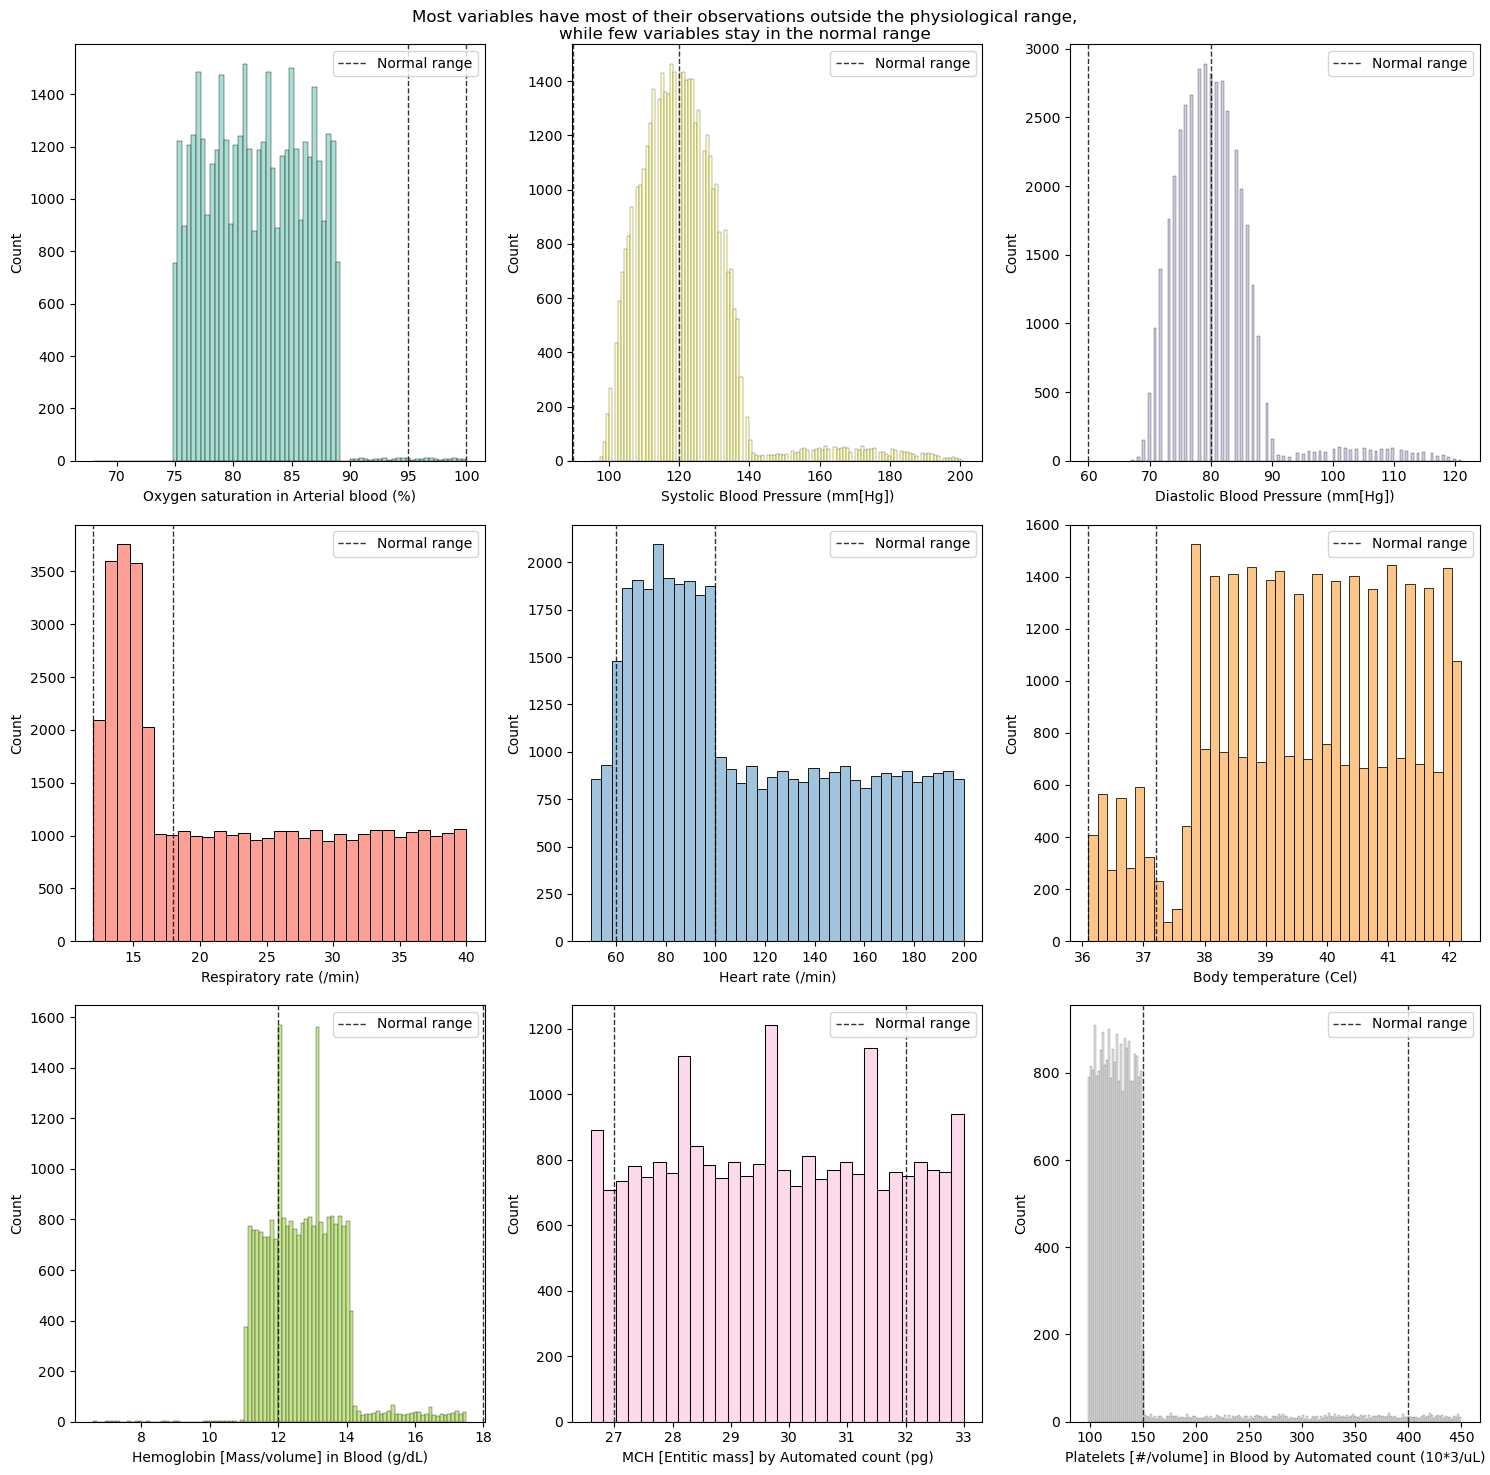

In [5]:
x = ['Oxygen saturation in Arterial blood',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Respiratory rate',
    'Heart rate',
    'Body temperature',
    'Hemoglobin [Mass/volume] in Blood',
    'MCH [Entitic mass] by Automated count',
    'Platelets [#/volume] in Blood by Automated count'] # quito body weight pq hay mucha variabilidad por edad, sexo, etc
colors = ['#8dd3c7',
'#ffffb3',
'#bebada',
'#fb8072',
'#80b1d3',
'#fdb462',
'#b3de69',
'#fccde5',
'#d9d9d9']
physio_ranges = dict(zip(x,
                         [(95, 100), # oxygen [1]
                          (90, 120), # sys [2]
                          (60, 80), # dias [3]
                          (12, 18), # resp [4]
                          (60, 100), # heart [5]
                          (36.1, 37.2), # temp [6]
                          (12, 18), # hemoglobin [7]
                          (27, 32), # MCH [8]
                          (150, 400)])) # platelets [9] 10**3
fig, axs = plt.subplots(3, 3, figsize=(15,15))
data = covid[covid['obs_desc'].isin(x)].groupby('obs_desc', observed=False)
#units = data['units'].drop_duplicates().astype('string').to_list()
x = iter(x)
for i, ax in enumerate(axs.flatten()):
    xx = next(x)
    group = data.get_group(xx)
    sns.histplot(x = group['num_val'],
                 ax = ax,
                 fill = True,
                 color = colors[i])
    ax.axvline(physio_ranges[xx][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
    ax.axvline(physio_ranges[xx][1], ls='--', alpha=0.8, color='k', lw=1)
    ax.set_xlabel(f'{xx} ({group['units'].drop_duplicates().astype('string').item()})');
    ax.legend(loc='upper right');
fig.suptitle('Most variables have most of their observations outside the physiological range,\nwhile few variables stay in the normal range')
fig.tight_layout();

In [6]:
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 90, 110]
age_labels = ['<18', '18-29', '30-39', '40-49','50-59', '60-69','70-79', '80-89','90+']
covid['age_at_obs'] = (covid['date'] - covid['birthdate']).dt.days / 365
covid['median_age'] = covid.groupby('patient')['age_at_obs'].transform('median')
covid['age_group'] = pd.cut(covid['age_at_obs'],
                            bins=age_bins,
                            labels=age_labels,
                            right=False
                           )
covid_start = (conditions
    [conditions['DESCRIPTION'] == 'COVID-19'][['START', 'PATIENT']]
    .rename(columns = {
        'START': 'covid_start',
        'PATIENT': 'patient'})
    .astype({'covid_start': 'datetime64[ns]'})           
              )
covid = covid.merge(covid_start, on='patient', how='left')

data1 = (conditions
            [conditions['PATIENT'].isin(covid_mask)][['DESCRIPTION']]
            .value_counts()
            .drop('COVID-19', level=0)
            .reset_index(name='count')
            .head(20)
            .rename(columns={'DESCRIPTION': 'Illness'})
         )
death_mask = (covid
    .drop_duplicates(subset=['patient'])[['patient','deathdate']]
    .dropna(subset=['deathdate'])['patient']
    .reset_index(drop=True))
covid['death'] = covid['patient'].isin(death_mask)

data2 = (covid
         [covid['obs_desc'] == 'Body Weight']
         .pivot_table(
             index = ['date', 'patient', 'death', 'median_age'], # para quitar bug3: ['patient', 'death', 'median_age']
             columns = 'obs_desc',
             values = 'num_val',
         )
         .reset_index()
)

data3 = (covid
         .pivot_table(
             index = 'obs_code',
             columns = 'age_group',
             values = 'num_val',
             aggfunc = 'count',
             observed = False,
             dropna = False,
         )
)
threshold = 100
data3_filtered = data3[data3.sum(axis=1) >= threshold]
data3_filtered = data3_filtered.loc[:, data3_filtered.sum(axis=0) >= threshold] # quitar con menos de 100 observaciones

x4 = 'Platelets [#/volume] in Blood by Automated count'
data4 = covid[covid['obs_desc'] == x4][['date', 'num_val', 'covid_start']]

del death_mask, threshold, data3, age_bins, age_labels, covid_start

Al reproducir esta figura del laboratorio 03 vemos que los resultados no cambian así que el bug es muy silencioso.

A continuación reciclo código para reproducir otra figura que generé en el laboratorio 03. Esto me servirá para resolver un bug no intencional (__este será el tercer issue__) del que me di cuenta hasta que estaba trabajando en este laboratorio: al hacer el pivot_table necesario para crear la variable "data2" que uso para el scatterplot del segundo panel, accidentalmente hice el pivoting usando también la columna 'date' en el parámetro index. Esto implica que los timestamps individuales no permiten que se haga promedio por pacientes Esto quiere decir que mi gráfica (que muestra body weight vs diastolic blood pressure con código de color para pacientes vivos/muertos) puede tener 50 puntos rojos pertenecientes a un solo paciente muerto, si es que a ese paciente se le hicieron 50 mediciones de peso y presión sanguínea durante un encuentro largo, e.g., una estadía de una semana en el hospital. Esto puede estar sesgando gravemente los resultados. Lo ideal sería sacar la variable date del index, de manera que se pueda calcular media/mediana por paciente. Este bug también lo aprovecharé para practicar el manejo de issues y PRs.

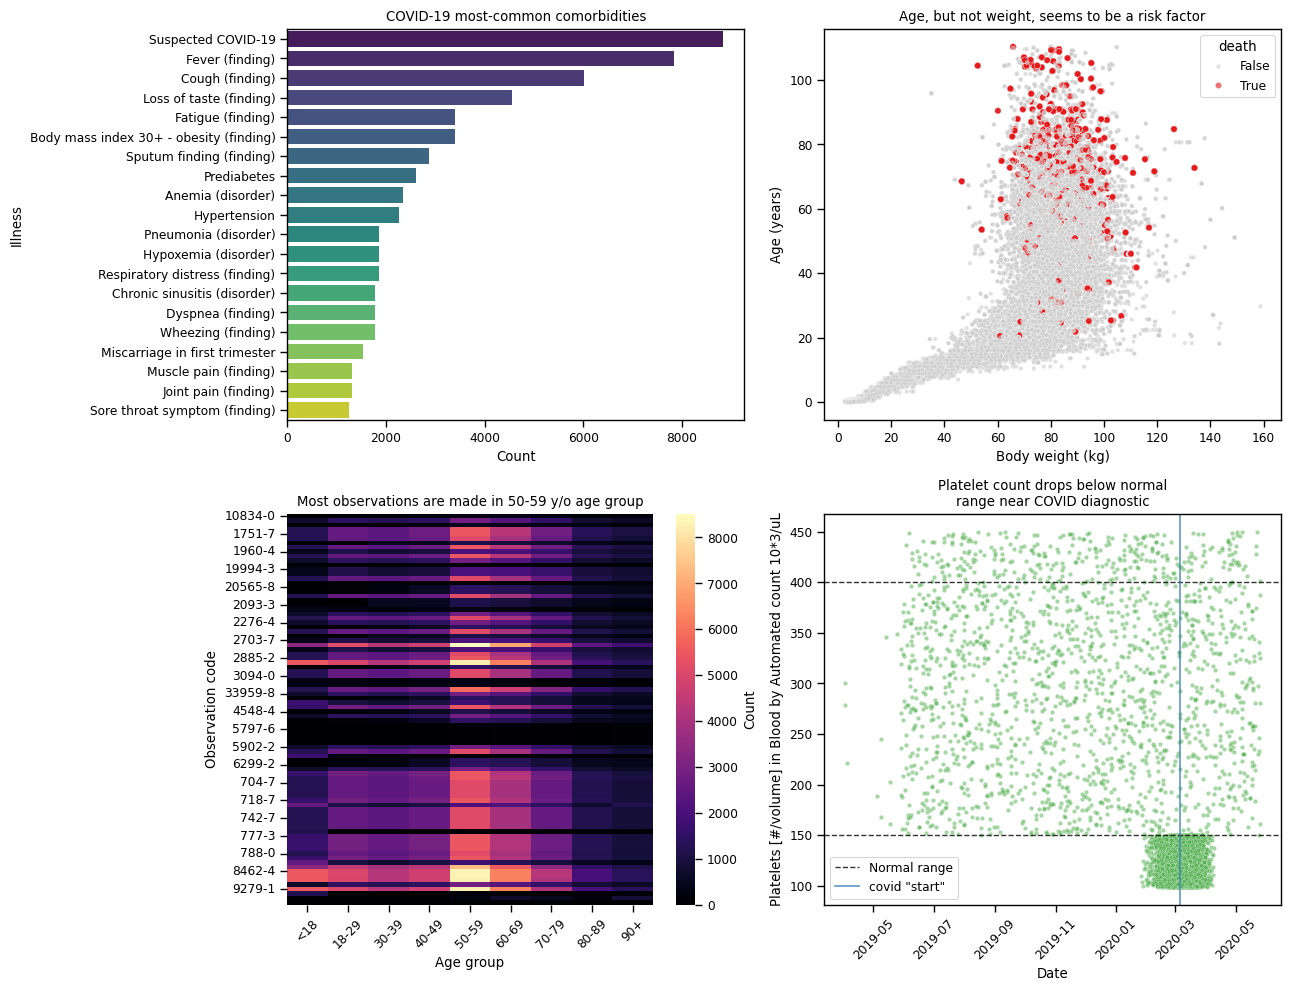

In [7]:
sns.set_context('paper')
fig, axs = plt.subplots(2, 2, figsize=(13,10))
axs = axs.flatten()
sns.barplot(
    data = data1,
    x = 'count',
    y = 'Illness',
    palette = 'viridis',
    hue = 'Illness',
    legend = False,
    ax = axs[0])
axs[0].set_title('COVID-19 most-common comorbidities');
axs[0].set_xlabel('Count')

sns.scatterplot(
    data = data2,
    x = 'Body Weight',
    y = 'median_age',
    hue = 'death',
    palette = {True: '#e41a1c', False: '#cccccc'},
    size = 'death',
    sizes = {True: 20, False: 10},
    alpha = 0.6,
    ax = axs[1]);
axs[1].set_ylabel('Age (years)')
axs[1].set_xlabel('Body weight (kg)');
axs[1].set_title('Age, but not weight, seems to be a risk factor');

sns.heatmap(
    data3_filtered,
    cmap='magma',
    cbar_kws={'label': 'Count'},
    ax = axs[2]);
axs[2].set_ylabel('Observation code')
axs[2].set_title('Most observations are made in 50-59 y/o age group')
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Age group')

sns.scatterplot(
    data = data4,
    x = 'date',
    y = 'num_val',
    alpha = 0.5,
    s = 10,
    color = '#4daf4a',
    ax = axs[3])
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_ylabel(x4 + ' 10*3/uL')
axs[3].axhline(physio_ranges[x4][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
axs[3].axhline(physio_ranges[x4][1], ls='--', alpha=0.8, color='k', lw=1)
axs[3].axvline(data4['covid_start'].dropna().median(), label='covid "start"', alpha=0.8, color='#377eb8')
axs[3].legend(loc='lower left')
axs[3].set_title('Platelet count drops below normal\nrange near COVID diagnostic');
axs[3].set_xlabel('Date');
fig.tight_layout();

Afortunadamente la gráfica no cambia demasiado, a pesar de que se estaban graficando ~39k puntos en vez de los ~8k (lo confirmo acá abajo) que esperaba. Muy probablemente lo que está pasando es que los puntos sobrantes están saturando los puntos grises y por eso la interpretación de la gráfica sigue siendo la misma. De cualquier manera lo mantengo con el bug para corregirlo dentro usando un PR.

In [10]:
data2a = (covid
         [covid['obs_desc'] == 'Body Weight']
         .pivot_table(
             index = ['date', 'patient', 'death', 'median_age'], # original, para tener bug: ['date', 'patient', 'death', 'median_age']
             columns = 'obs_desc',
             values = 'num_val',
         )
         .reset_index()
)

data2b = (covid
         [covid['obs_desc'] == 'Body Weight']
         .pivot_table(
             index = ['patient', 'death', 'median_age'], # original, para tener bug: ['date', 'patient', 'death', 'median_age']
             columns = 'obs_desc',
             values = 'num_val',
         )
         .reset_index()
)

print(data2a.shape, data2b.shape)

(39226, 5) (8820, 4)


0
Total dots plotted: 39226
1
Total dots plotted: 8820


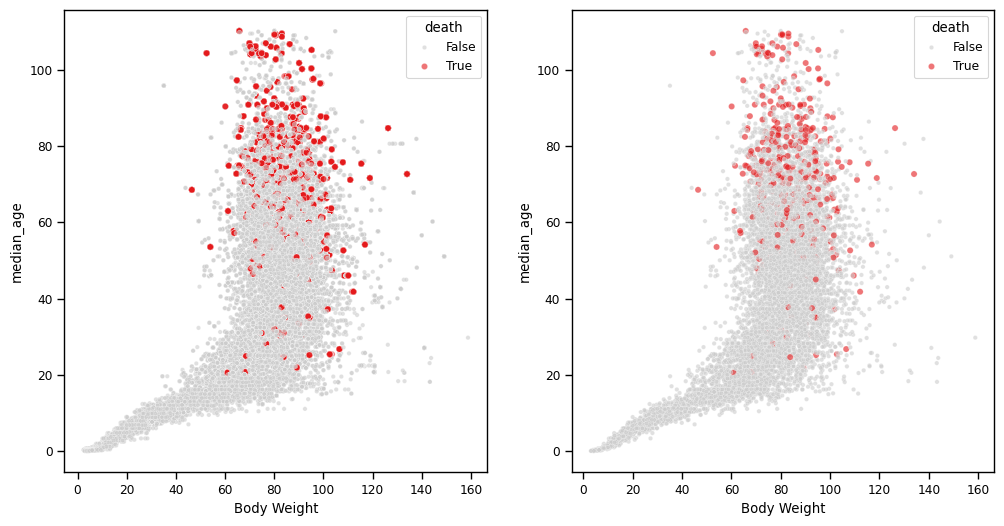

In [11]:
fig, axs = plt.subplots(1, 2, figsize = (12,6))
datas = (data2a, data2b)
for i, ax in enumerate(axs):
    sns.scatterplot(
        data = datas[i],
        x = 'Body Weight',
        y = 'median_age',
        hue = 'death',
        palette = {True: '#e41a1c', False: '#cccccc'},
        size = 'death',
        sizes = {True: 20, False: 10},
        alpha = 0.6,
        ax = ax);
    total_points = sum(len(col.get_offsets()) for col in ax.collections)
    print(i)
    print(f'Total dots plotted: {total_points}')